### Завдання 1
Створіть тензори та виконайте базові операції.
- Уявіть, що кожен тензор — це стовпець даних про клієнтів (вік, вага, зріст).
- Створіть 1D, 2D і 3D тензори(torch.manual_seed(42)).
- Виконайте операції додавання і поелементного множення, щоб обчислити умовний показник ризику.
- Увімкніть requires_grad=True для одного тензора, перевірте наявність grad_fn.

In [5]:
import torch

In [6]:
torch.manual_seed(42)
age = torch.randint(18, 70, (5, ), dtype=torch.float32)
age

tensor([36., 65., 50., 48., 48.])

Тензор у математиці — це узагальнене поняття для матриці (бгато мірній масив)

In [7]:
age = torch.randn(5)
print(age)
age = 44.0 + 26.0 * age
print(age)

tensor([ 0.3258, -0.8676,  1.5231,  0.6647, -1.0324])
tensor([52.4695, 21.4417, 83.6015, 61.2813, 17.1564])


In [8]:
age_wigth_height = torch.randn(5, 3)
age_wigth_height

tensor([[-0.2770, -0.1671, -0.1079],
        [-1.4285, -0.2810,  0.7489],
        [ 1.1164,  1.2931,  0.4137],
        [-0.5710, -0.9749,  0.1863],
        [ 1.6273,  1.1214, -0.6605]])

In [9]:
with torch.no_grad():
    age_wigth_height[:,0] = 44.0  + 16.0 * age_wigth_height[:,0]
    age_wigth_height[:,1] = 95.0  + 26.0 * age_wigth_height[:,1]
    age_wigth_height[:,2] = 180.0 + 15.0 * age_wigth_height[:,2]
age_wigth_height

tensor([[ 39.5675,  90.6545, 178.3816],
        [ 21.1435,  87.6947, 191.2339],
        [ 61.8628, 128.6203, 186.2059],
        [ 34.8640,  69.6514, 182.7952],
        [ 70.0362, 124.1575, 170.0919]])

In [10]:
risk = age_wigth_height[:,0]  * age_wigth_height[:,1] + 0.5 * age_wigth_height[:,2]
risk = (risk - risk.min()) / (risk.max() - risk.min())
risk

tensor([0.2527, 0.0000, 0.8930, 0.0834, 1.0000])

### Завдання 2
Реалізуйте персептрон для передбачення ризику клієнта.
- Згенеруйте дані (torch.randn, 100 зразків, 1 ознака — індекс маси тіла).
- Цільова змінна — умовний "ризик" (лінійна комбінація + шум).
- Побудуйте модель nn.Linear(1, 1) і функцію втрат MSE.
- Виконайте 20 епох навчання з ручним оновленням параметрів.
- Виведіть початкові та фінальні значення ваг і loss.

In [11]:
bmi = torch.randn (100,1)
print(bmi[:5])
risk = 0.1 * bmi + torch.rand(100,1)
# risk = 0.1 * bmi + noise
print(risk[:5])

tensor([[ 0.6872],
        [-1.0892],
        [-0.3553],
        [-0.9138],
        [-0.6581]])
tensor([[0.6786],
        [0.4554],
        [0.0238],
        [0.6185],
        [0.3592]])


In [12]:
import torch.nn as nn
import torch.optim as optim

class Perceptron(nn.Module) :
    def __init__(self) :
        super(Perceptron, self).__init__()
        self.layer1 = nn.Linear(1,1)
        self.activation = nn.Sigmoid()
    def forward(self, x) :
        x = self.layer1(x)
        x = self.activation(x)
        return x
loss_f = nn.functional.mse_loss 

In [13]:
model = Perceptron()
learning_rate = 0.01

for epoch in range(20):
    output = model(bmi)
    loss = loss_f(output,risk)
    loss.backward()

    with torch.no_grad() :
        for param in model.parameters() :
            param -= learning_rate * param.grad
            param.grad.zero_()
    print(f"Epoch: {epoch}, loss: {loss.item():.4f}")

Epoch: 0, loss: 0.1726
Epoch: 1, loss: 0.1725
Epoch: 2, loss: 0.1725
Epoch: 3, loss: 0.1724
Epoch: 4, loss: 0.1723
Epoch: 5, loss: 0.1722
Epoch: 6, loss: 0.1722
Epoch: 7, loss: 0.1721
Epoch: 8, loss: 0.1720
Epoch: 9, loss: 0.1720
Epoch: 10, loss: 0.1719
Epoch: 11, loss: 0.1718
Epoch: 12, loss: 0.1717
Epoch: 13, loss: 0.1717
Epoch: 14, loss: 0.1716
Epoch: 15, loss: 0.1715
Epoch: 16, loss: 0.1714
Epoch: 17, loss: 0.1714
Epoch: 18, loss: 0.1713
Epoch: 19, loss: 0.1712


### Завдання 3
Навчіть той самий персептрон з оптимізатором SGD, щоб прискорити збіжність.
- Налаштуйте torch.optim.SGD(lr = 0.01).
- Виконайте 20 епох, фіксуючи loss.
- Заповніть таблицю:

In [31]:
model2 = Perceptron()
bmi2 =torch.randn(100, 1)
noise2 = 0.1 * torch.randn(100, 1)
risk2 = 0.1 * bmi2 + noise2
lossees2 = []
optimizer = optim.SGD(model2.parameters(), lr=0.1)
print(optimizer)

for epoch in range(20):
    output2 = model2(bmi2)
    loss = loss_f(output2,risk2)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    lossees2.append(loss.item())
lossees2

SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.1
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)


[0.3220262825489044,
 0.31416255235671997,
 0.3064689636230469,
 0.29894953966140747,
 0.29160746932029724,
 0.2844451069831848,
 0.2774638533592224,
 0.2706645429134369,
 0.26404711604118347,
 0.2576110363006592,
 0.25135499238967896,
 0.24527734518051147,
 0.23937591910362244,
 0.23364809155464172,
 0.22809095680713654,
 0.222701296210289,
 0.21747568249702454,
 0.21241040527820587,
 0.20750167965888977,
 0.20274552702903748]

### Завдання 4
Побудуйте графік залежності втрат від епох і зробіть висновок:
- Як швидко знижується помилка?
- Який діапазон ваг забезпечує мінімальний ризик?
- Збережіть графік у файл loss_healthrisk.png.

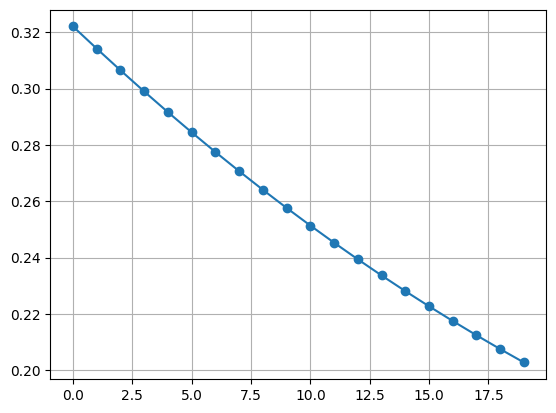

In [44]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
plt.grid(True)
ax.plot(lossees2 , 'o-')
plt.savefig("loss.png")

In [42]:
for name, param in model2.named_parameters():
    print(name, param.data)

layer1.weight tensor([[0.2145]])
layer1.bias tensor([-0.2495])
